In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-23 13:54:38.639366


Reran with updated annotatiosn with g1/g2

# Single and double-positive neuron proportions

Test filtering to just cells with > 1k transcripts for cleaning up UMAP

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 300

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes"
adata_path = input_dir / "neurons-final-labels.h5ad"

In [5]:
adata = sc.read_h5ad(adata_path)

In [6]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

In [7]:
assign_cell_type_colors(adata,  key="neuron_labels")

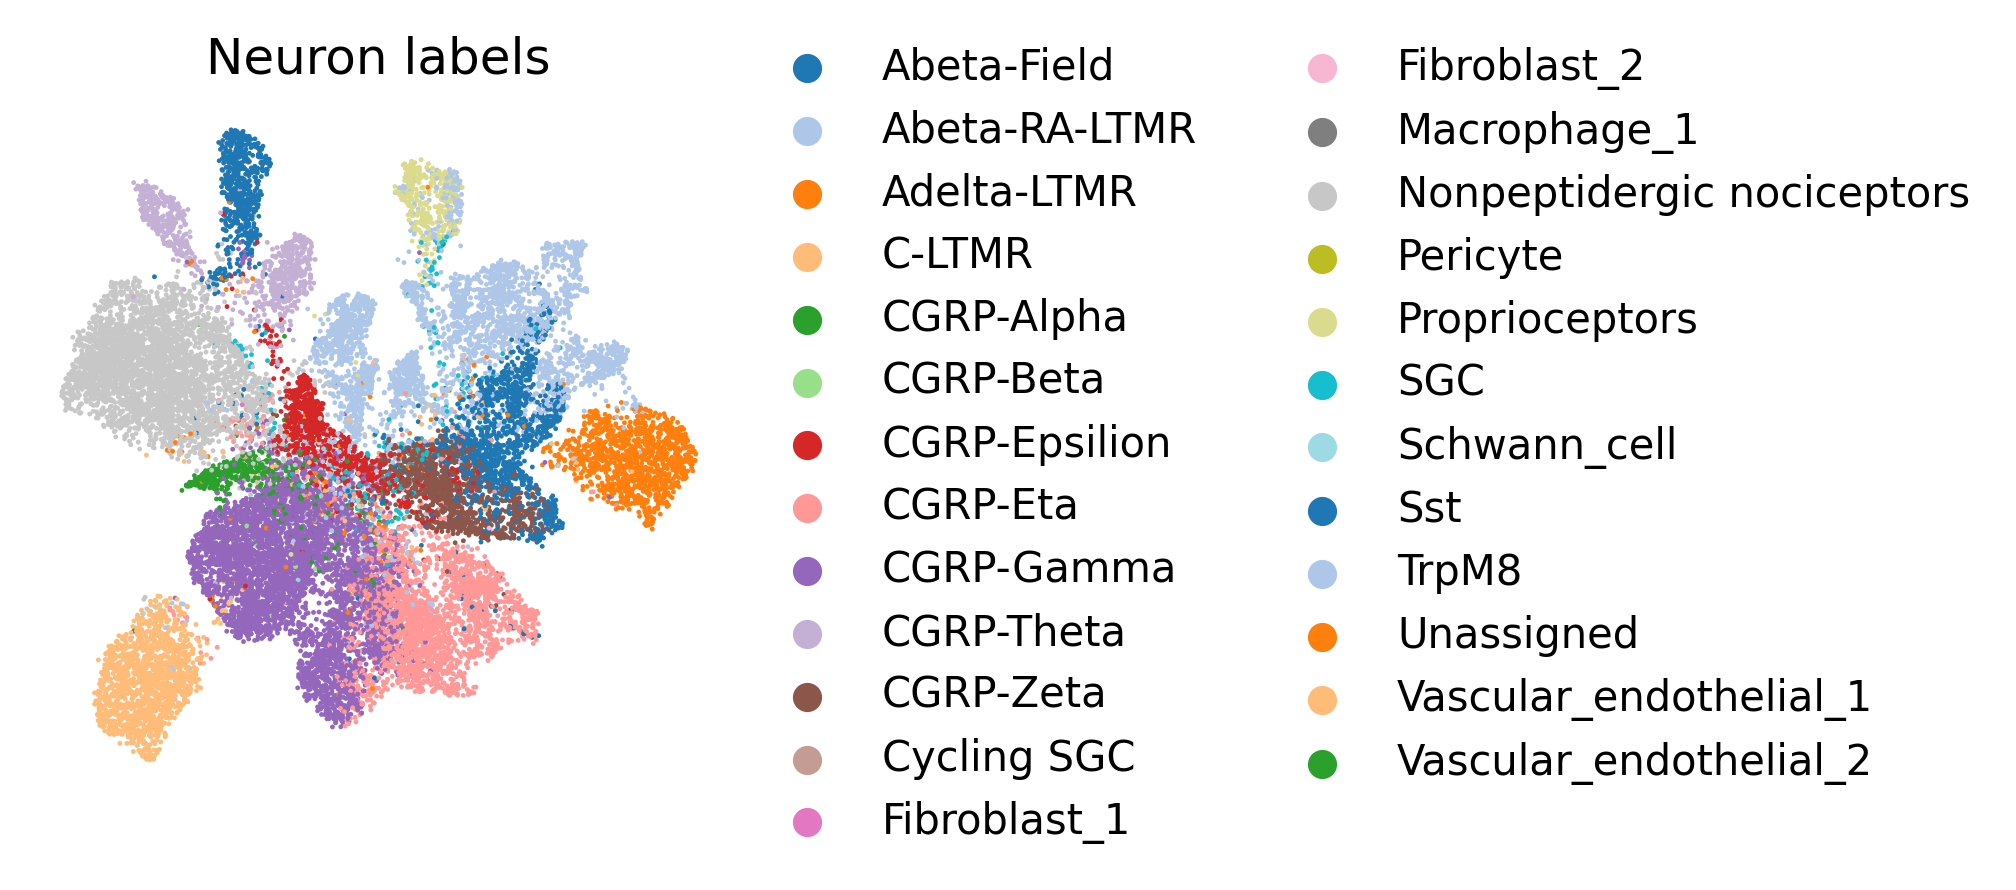

In [8]:
sc.pl.umap(adata, color = 'scanvi_labels', frameon = False, title = 'Neuron labels')

# Visualization

### Single-dual-positive counts

In [9]:
def plot_tracing_barchart(
    adata,
    egfp_col="EGFP_Seq1_hi",
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    colors=None,
    figsize=(3, 3)
):
    """
    Plot counts of EGFP+, dTomato+, and dual-positive cells.
    """

    # Default colors
    if colors is None:
        colors = {
            "EGFP": "limegreen",
            "dTomato": "crimson",
            "Dual": "gold",
        }

    # Check columns
    for col in [egfp_col, dtom_col, dual_col]:
        if col not in adata.obs.columns:
            raise ValueError(f"Column `{col}` not found in adata.obs")

    # Extract counts
    n_egfp = adata.obs[egfp_col].sum()
    n_dtom = adata.obs[dtom_col].sum()
    n_dual = adata.obs[dual_col].sum()

    categories = ["EGFP+", "dTomato+", "Dual+"]
    counts = [n_egfp, n_dtom, n_dual]
    plot_colors = [colors["EGFP"], colors["dTomato"], colors["Dual"]]

    # Plot
    plt.figure(figsize=figsize)
    bars = plt.bar(categories, counts, color=plot_colors, edgecolor="black")

    # Add labels above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.ylabel("Number of cells")
    plt.title("Counts of Single and Dual-Positive Cells")
    plt.tight_layout()
    plt.show()

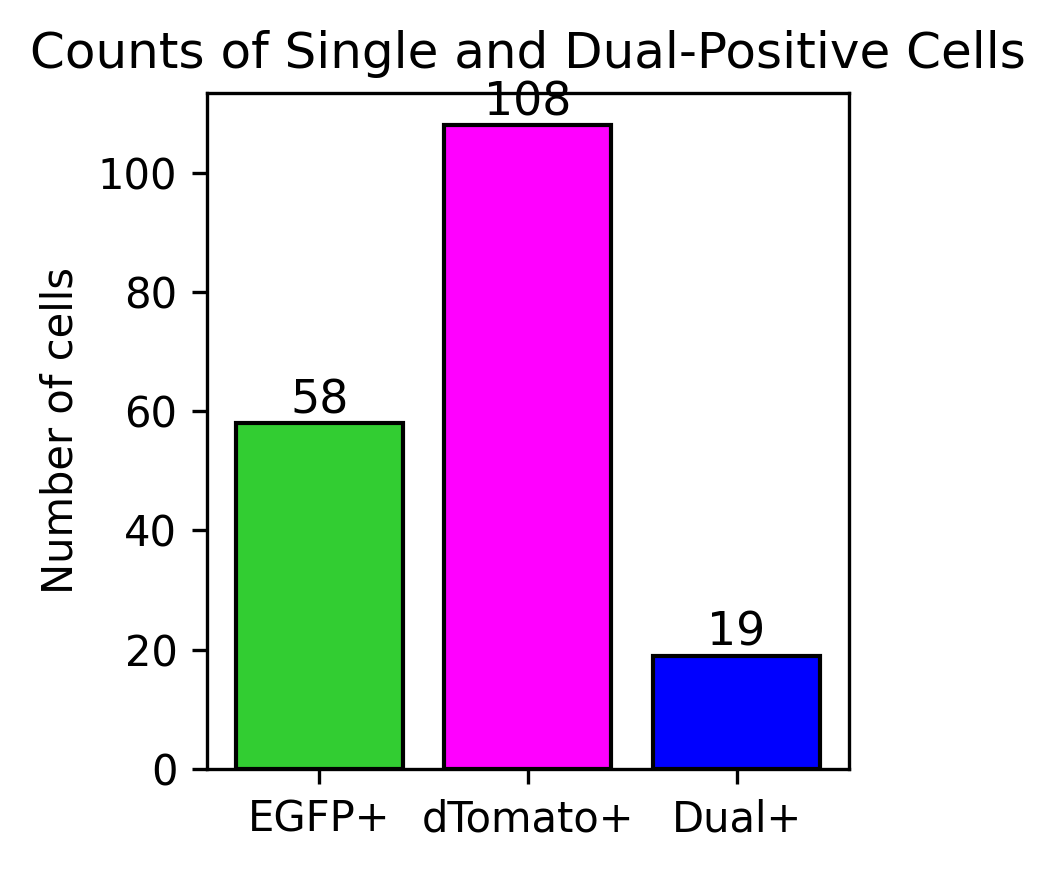

In [10]:
plot_tracing_barchart(
    adata,
    colors={
        "EGFP": "limegreen",
        "dTomato": "magenta",
        "Dual": "blue"
    }
)

### Single-dual-positive proportion

In [11]:
def plot_dual_fraction_among_dtom(
    adata,
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    colors=None,
    figsize=(3, 3)
):
    """
    Visualize what fraction of dTomato+ cells are dual+.
    Produces both raw counts and a percent bar chart.
    """

    # Default colors
    if colors is None:
        colors = {
            "Single": "crimson",   # dTom only
            "Dual": "gold"         # dTom + EGFP
        }

    # Check columns
    for col in [dtom_col, dual_col]:
        if col not in adata.obs.columns:
            raise ValueError(f"Column `{col}` not found in adata.obs")

    # Boolean masks
    dtom_mask = adata.obs[dtom_col].astype(bool)
    dual_mask = adata.obs[dual_col].astype(bool)

    # Counts
    n_dtom_total = dtom_mask.sum()
    n_dual = (dtom_mask & dual_mask).sum()
    n_dtom_only = n_dtom_total - n_dual

    # Fractions
    frac_dual = n_dual / n_dtom_total if n_dtom_total > 0 else 0
    frac_single = 1 - frac_dual

    categories = ["dTom-only", "Dual+"]
    values = [n_dtom_only, n_dual]
    plot_colors = [colors["Single"], colors["Dual"]]

    # Plot
    plt.figure(figsize=figsize)
    bars = plt.bar(categories, values, color=plot_colors, edgecolor="black")

    # Add labels
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val,
            f"{val}\n({val/n_dtom_total*100:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.ylabel("Number of cells")
    plt.title(f"Dual+ Fraction Among dTomato+ Cells\nDual = {frac_dual*100:.1f}%")
    plt.tight_layout()
    plt.show()

    return {
        "n_dTom_total": n_dtom_total,
        "n_dual": n_dual,
        "n_dtom_single": n_dtom_only,
        "fraction_dual": frac_dual
    }

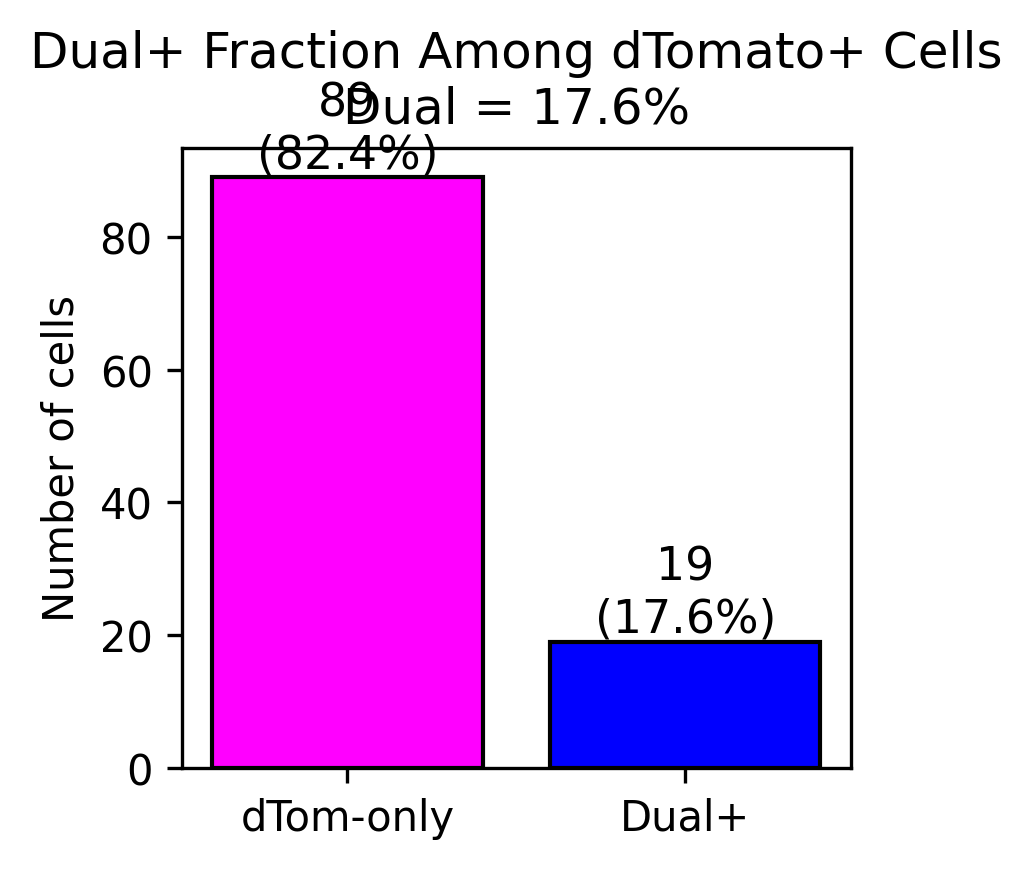

In [12]:
stats = plot_dual_fraction_among_dtom(
    adata,
    colors={
        "Single": "magenta",
        "Dual": "blue"
    }
)

### UMAP

In [13]:
def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")           # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

In [14]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

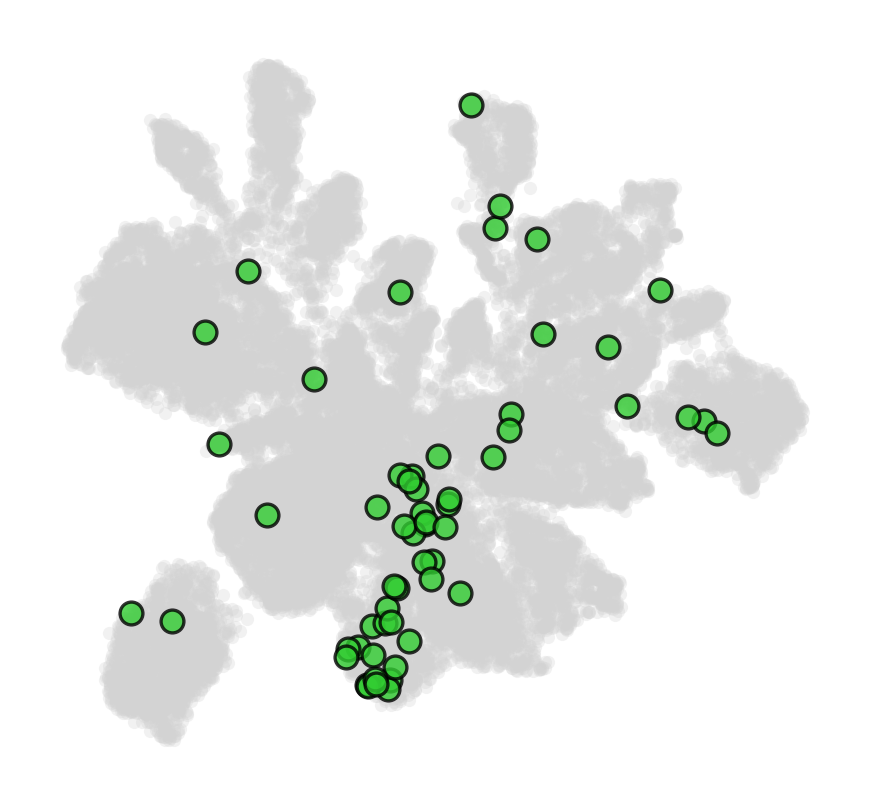

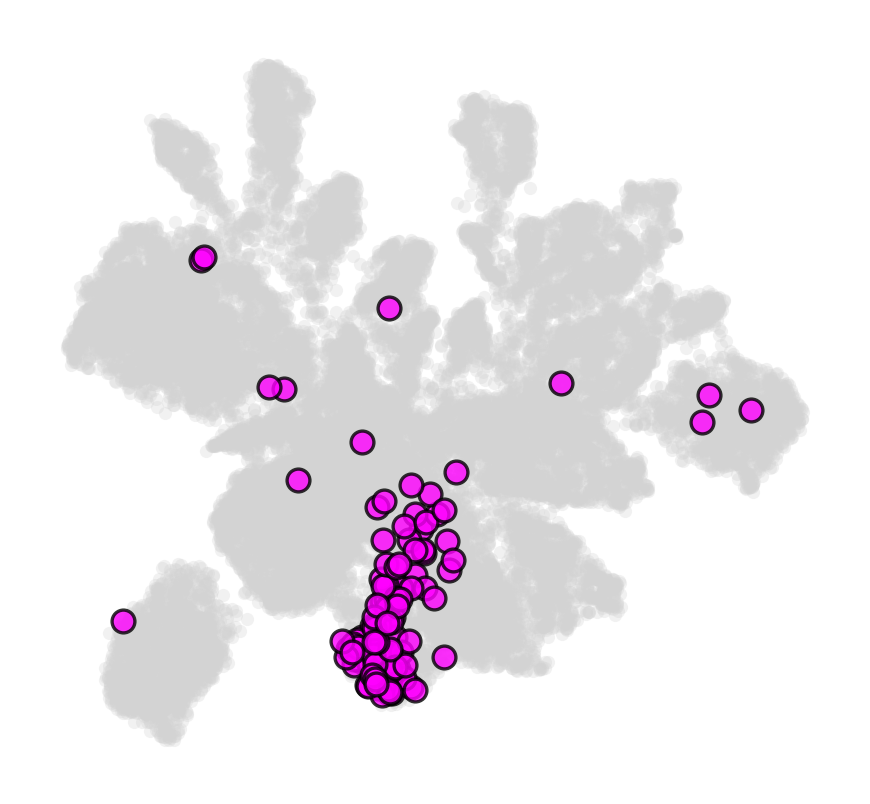

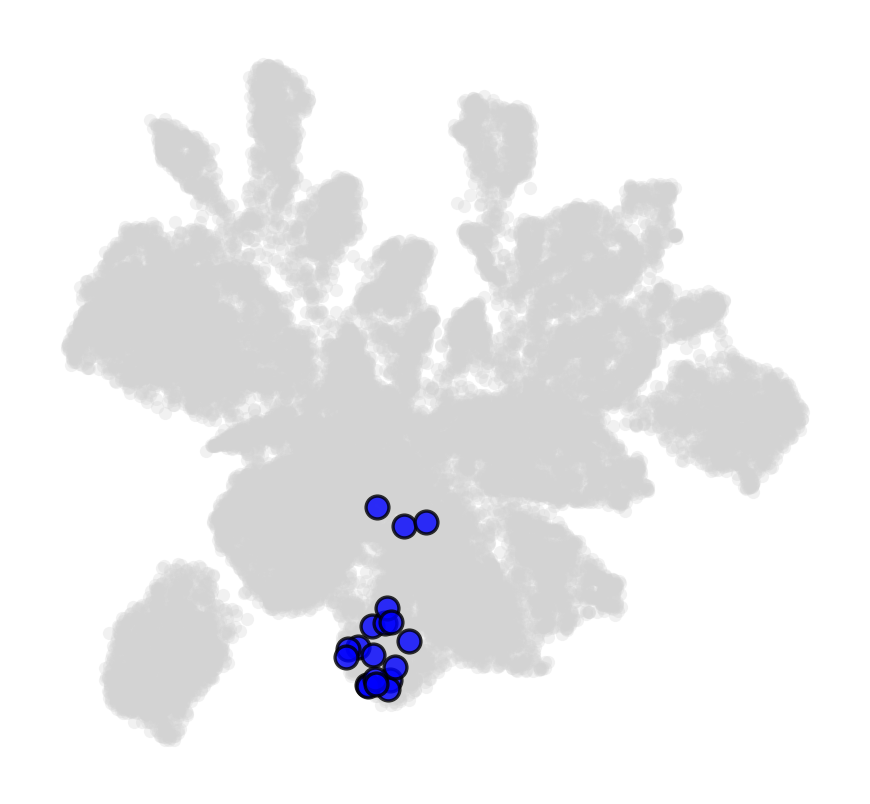

In [15]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
)

# Summary

In [16]:
# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table including neuron_recluster_seurat
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "neuron_labels": adata.obs["neuron_labels"],
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "confidence": adata.obs["confidence"],
    "neuron_recluster": adata.obs["neuron_recluster_seurat"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

df

,barcode,neuron_labels,seurat_label,scanvi_label,confidence,neuron_recluster,EGFP_single,dTom_single,Dual_positive
aaadagcf-1,aaadagcf-1,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,NaN,1,False,False,False
aaaihgjh-1,aaaihgjh-1,Adelta-LTMR,Adelta-LTMR,Adelta-LTMR,NaN,6,False,False,False
aabcohae-1,aabcohae-1,Adelta-LTMR,Adelta-LTMR,Adelta-LTMR,NaN,6,False,False,False
aabdncpn-1,aabdncpn-1,Proprioceptors,Proprioceptors,Proprioceptors,NaN,11,False,False,False
aacblkbe-1,aacblkbe-1,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,NaN,1,False,False,False
...,...,...,...,...,...,...,...,...,...
ncikkhpf-1,ncikkhpf-1,CGRP-Eta,CGRP-Eta,CGRP-Eta,NaN,2,False,False,False
ncikogkk-1,ncikogkk-1,CGRP-Epsilion,CGRP-Epsilion,CGRP-Theta,NaN,7,False,False,False
ncpkkekg-1,ncpkkekg-1,CGRP-Eta,CGRP-Eta,CGRP-Eta,NaN,2,False,False,False
ndabchac-1,ndabchac-1,Abeta-Field,Abeta-Field,Abeta-Field,NaN,3,False,False,False


In [17]:
df[df["EGFP_single"]][["barcode", "seurat_label", "scanvi_label", "confidence", "neuron_recluster"]]

,barcode,seurat_label,scanvi_label,confidence,neuron_recluster
aogalboa-1,aogalboa-1,CGRP-Gamma,CGRP-Eta,NaN,2
ckgddhbd-1,ckgddhbd-1,CGRP-Eta,SGC,NaN,11
ahgdffna-1,ahgdffna-1,CGRP-Eta,CGRP-Eta,NaN,3
akfjbdhd-1,akfjbdhd-1,TrpM8,Pericyte,NaN,0
canljbbi-1,canljbbi-1,CGRP-Gamma,CGRP-Gamma,NaN,0
eaiehejo-1,eaiehejo-1,Abeta-Field,Adelta-LTMR,NaN,6
ihadecfn-1,ihadecfn-1,CGRP-Gamma,CGRP-Gamma,NaN,2
ilophdlj-1,ilophdlj-1,CGRP-Zeta,CGRP-Zeta,NaN,3
lllnlabg-1,lllnlabg-1,CGRP-Gamma,CGRP-Gamma,NaN,2
llneboie-1,llneboie-1,Proprioceptors,Pericyte,NaN,2


In [18]:
df[df["dTom_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
achecihm-1,achecihm-1,CGRP-Gamma,CGRP-Gamma,NaN
aemkjdhf-1,aemkjdhf-1,CGRP-Gamma,CGRP-Gamma,NaN
agbmnepe-1,agbmnepe-1,CGRP-Gamma,CGRP-Gamma,High
behbjfkc-1,behbjfkc-1,CGRP-Gamma,Pericyte,NaN
bekmepom-1,bekmepom-1,CGRP-Gamma,CGRP-Gamma,NaN
...,...,...,...,...
apodpaed-1,apodpaed-1,CGRP-Gamma,CGRP-Gamma,NaN
dhlbnpjp-1,dhlbnpjp-1,CGRP-Gamma,CGRP-Eta,NaN
gkcjkgon-1,gkcjkgon-1,CGRP-Gamma,CGRP-Gamma,NaN
jmdegfji-1,jmdegfji-1,CGRP-Gamma,CGRP-Gamma,NaN


In [19]:
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence", "neuron_recluster"]]

,barcode,seurat_label,scanvi_label,confidence,neuron_recluster
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High,2
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High,2
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High,2
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High,2
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High,0
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High,2
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High,2
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN,2
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,High,2
ajnphbmj-1,ajnphbmj-1,CGRP-Gamma,CGRP-Gamma,NaN,2


# Donut

In [20]:
def set_seurat_palette_and_legend(
    adata,
    seurat_col="seurat_labels",
    ncols=2  
):
    """
    Assigns a consistent color palette and draws ONE global legend.
    """
    adata.obs[seurat_col] = adata.obs[seurat_col].astype("category")
    labels = adata.obs[seurat_col].cat.categories

    # TAB20 color palette
    palette = sns.color_palette("tab20", n_colors=len(labels))
    color_map = {label: mcolors.to_hex(col) for label, col in zip(labels, palette)}

    # Store in adata for Scanpy consistency
    adata.uns[f"{seurat_col}_colors"] = list(color_map.values())

    # --- Draw global legend ---
    # Height based on how many rows after splitting into n columns
    nrows = int(np.ceil(len(labels) / ncols))

    fig, ax = plt.subplots(figsize=(2 * ncols, 0.25 * nrows + 0.5))
    ax.axis("off")

    patches = [
        mpatches.Patch(color=color_map[label], label=label)
        for label in labels
    ]

    ax.legend(
        handles=patches,
        loc="center left",
        frameon=False,
        fontsize=8,
        ncol=ncols    # <--- HERE
    )

    plt.tight_layout()
    plt.show()

    return color_map

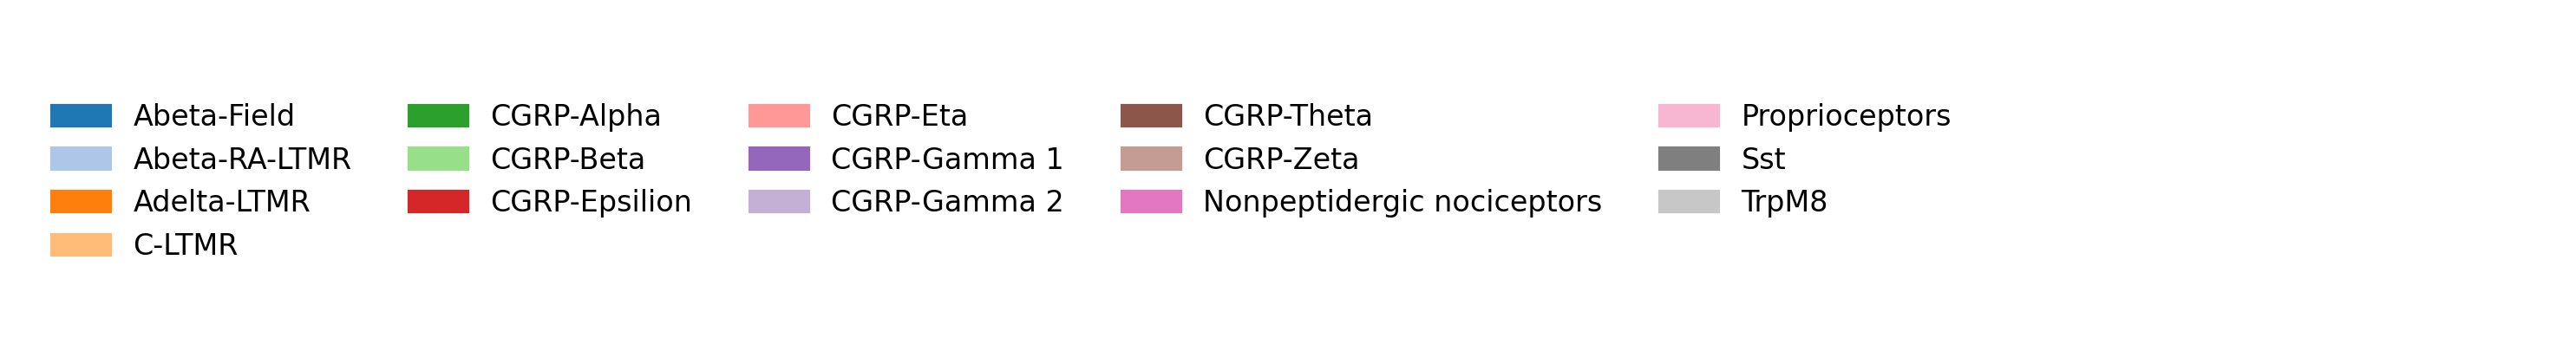

In [21]:
seurat_color_map = set_seurat_palette_and_legend(adata, "neuron_labels", ncols = 5)

In [22]:
def donut(
    adata,
    mask_col,
    seurat_col="neuron_labels",
    color_map=None,
    figsize=(3, 3),
    outer_border_color="black",
    outer_border_width=2,
    inner_border_color="black",
    inner_border_width=2,
    title=None
):
    """
    Donut showing TOP 5 Seurat labels among mask_col==True cells.
    Thicker donut ring (smaller hole).
    """

    if color_map is None:
        raise ValueError("Provide color_map from set_seurat_palette_and_legend().")

    # Boolean mask
    mask = adata.obs[mask_col].astype(bool)
    sub = adata[mask].copy()

    if sub.n_obs == 0:
        print(f"No cells found for {mask_col}")
        return None

    # Full summary counts
    full_counts = sub.obs[seurat_col].value_counts()
    full_perc = full_counts / full_counts.sum() * 100

    # Top 5 for donut plot
    top5 = full_counts.head(5)
    labels = top5.index.tolist()
    values = top5.values.astype(float)
    colors = [color_map[l] for l in labels]

    fig, ax = plt.subplots(figsize=figsize)

    # --- Thick donut ring ---
    wedgeprops = dict(width=0.55, edgecolor="white", linewidth=1)

    ax.pie(
        values,
        colors=colors,
        startangle=90,
        labels=None,
        wedgeprops=wedgeprops
    )

    # --- Smaller hole (inner circle) ---
    inner_circle = plt.Circle(
        (0, 0),
        0.45,
        color="white",
        ec=inner_border_color,
        lw=inner_border_width,
        zorder=10
    )
    ax.add_artist(inner_circle)

    # Outer border
    outer_circle = plt.Circle(
        (0, 0),
        1.0,
        fill=False,
        ec=outer_border_color,
        lw=outer_border_width,
        zorder=20
    )
    ax.add_artist(outer_circle)

    ax.set(aspect="equal")

    ax.set_title(title if title else mask_col, fontsize=14)

    plt.tight_layout()
    plt.show()

    # Return full summary DataFrame
    return pd.DataFrame({
        "label": full_counts.index,
        "count": full_counts.values,
        "percent": full_perc.values
    })

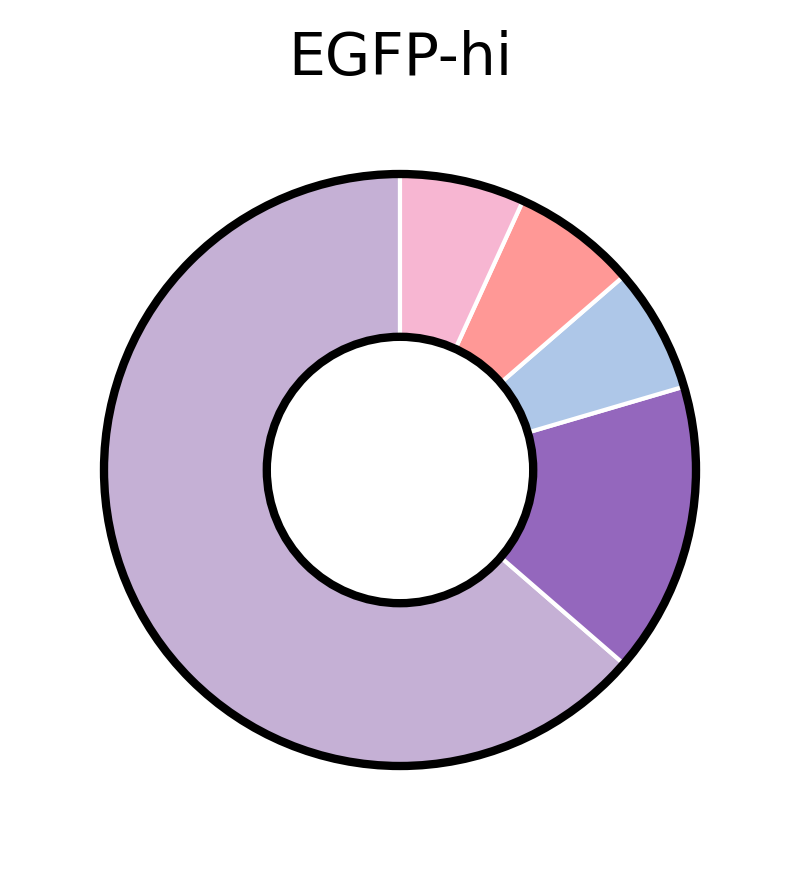

,label,count,percent
0,CGRP-Gamma 2,28,48.275862
1,CGRP-Gamma 1,7,12.068966
2,Abeta-RA-LTMR,3,5.172414
3,CGRP-Eta,3,5.172414
4,Proprioceptors,3,5.172414
5,Abeta-Field,2,3.448276
6,Adelta-LTMR,2,3.448276
7,C-LTMR,2,3.448276
8,CGRP-Zeta,2,3.448276
9,Nonpeptidergic nociceptors,2,3.448276


In [23]:
donut(adata, "EGFP_Seq1_hi", color_map=seurat_color_map, title = 'EGFP-hi')

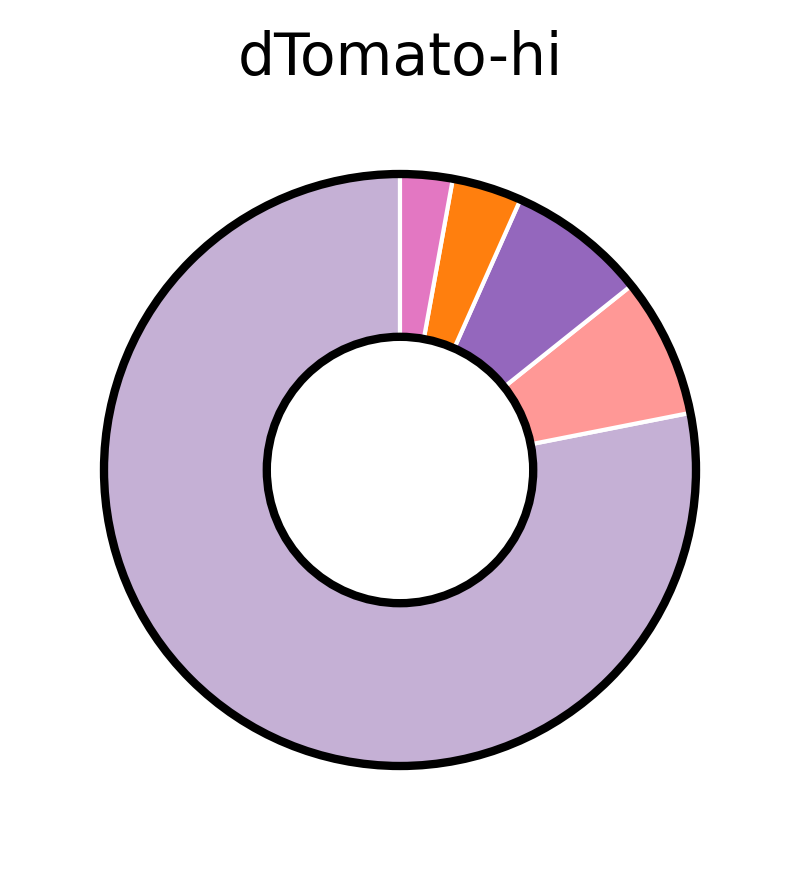

,label,count,percent
0,CGRP-Gamma 2,82,75.925926
1,CGRP-Eta,8,7.407407
2,CGRP-Gamma 1,8,7.407407
3,Adelta-LTMR,4,3.703704
4,Nonpeptidergic nociceptors,3,2.777778
5,Abeta-Field,1,0.925926
6,C-LTMR,1,0.925926
7,Proprioceptors,1,0.925926


In [24]:
donut(adata, "dTomato_Seq2_hi", color_map=seurat_color_map, title = 'dTomato-hi')

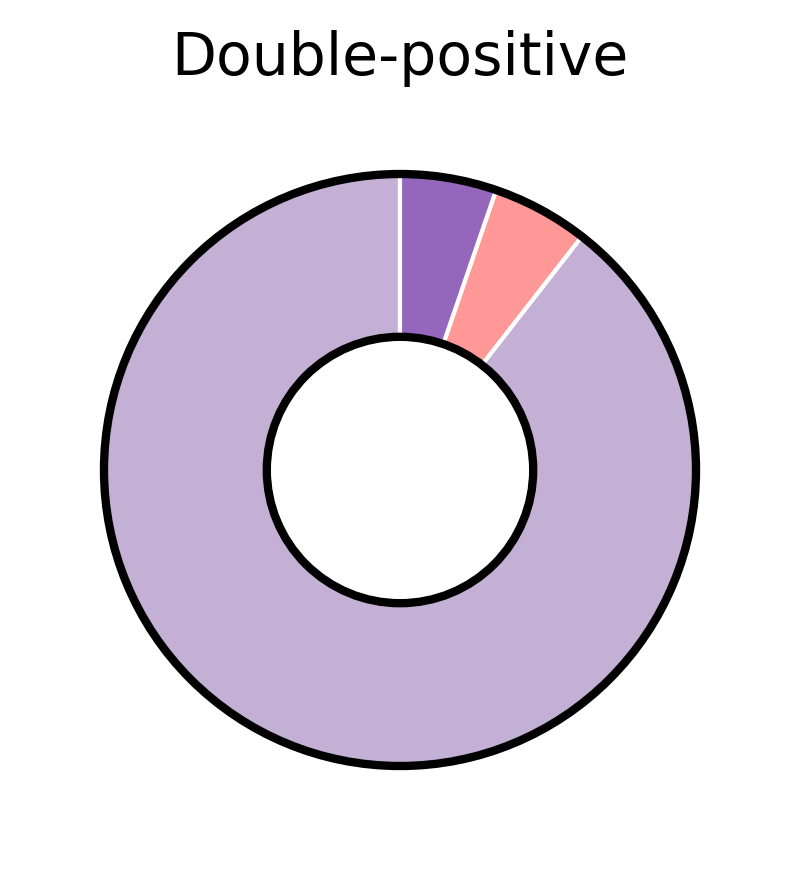

,label,count,percent
0,CGRP-Gamma 2,17,89.473684
1,CGRP-Eta,1,5.263158
2,CGRP-Gamma 1,1,5.263158


In [25]:
donut(adata, "EGFP_dTomato_dual_hi", color_map=seurat_color_map, title = 'Double-positive')

# Donut - dTomato

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def pie_dual_fraction(
    adata,
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    single_color="crimson",
    dual_color="gold",
    figsize=(3,3),
    outer_border_color="black",
    outer_border_width=2,
    title=None
):
    """
    Aesthetic pie chart (donut-style) showing the fraction
    of dTomato+ cells that are Dual+ vs Single.

    Parameters
    ----------
    title : str or None
        Custom plot title. If None, an automatic title is generated.
    """

    # --- Check columns ---
    for col in [dtom_col, dual_col]:
        if col not in adata.obs.columns:
            raise ValueError(f"Column `{col}` not found in adata.obs")

    # --- Boolean classification ---
    dtom_mask = adata.obs[dtom_col].astype(bool)
    dual_mask = adata.obs[dual_col].astype(bool)

    # --- Counts ---
    n_total = dtom_mask.sum()
    n_dual = (dtom_mask & dual_mask).sum()
    n_single = n_total - n_dual

    if n_total == 0:
        print("Warning: No dTomato+ cells found.")
        return None

    # --- Fractions ---
    values = np.array([n_single, n_dual], dtype=float)
    perc = values / values.sum() * 100

    colors = [single_color, dual_color]

    # --- Plot ----
    fig, ax = plt.subplots(figsize=figsize)

    wedges, _ = ax.pie(
        values,
        colors=colors,
        startangle=90,
        labels=None,
        wedgeprops=dict(edgecolor="white", linewidth=1)
    )

    # Inner white circle
    inner_circle = plt.Circle(
        (0,0),
        0.55,
        color="white",
        ec=outer_border_color,
        lw=outer_border_width,
        zorder=10
    )
    ax.add_artist(inner_circle)

    # Outer border
    outer_circle = plt.Circle(
        (0,0),
        1.0,
        fill=False,
        ec=outer_border_color,
        lw=outer_border_width,
        zorder=20
    )
    ax.add_artist(outer_circle)

    # Percent labels
    for i, w in enumerate(wedges):
        angle = (w.theta1 + w.theta2)/2
        x = np.cos(np.deg2rad(angle)) * 0.75
        y = np.sin(np.deg2rad(angle)) * 0.75
        ax.text(
            x, y,
            f"{perc[i]:.1f}%",
            ha="center",
            va="center",
            fontsize=11
        )

    # --- Title logic ---
    if title is None:
        title = f"Dual-positive fraction among {dtom_col} cells"

    ax.set(aspect="equal")
    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

    # Return stats
    return {
        "total_dTom": int(n_total),
        "n_single": int(n_single),
        "n_dual": int(n_dual),
        "percent_single": perc[0],
        "percent_dual": perc[1]
    }

In [27]:
summary = pie_dual_fraction(bdata, title = '')
summary

NameError: name 'bdata' is not defined

## bar

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

def bar_dual_fraction(
    adata,
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    single_color="crimson",
    dual_color="gold",
    bar_alpha=0.4,           # << alpha for bar FILL
    figsize=(4, 2.4),
    bar_height=0.45,
    edge_width=2,
    title=None,
    fontsize=11
):
    """
    Horizontal bar plot showing Single+ vs Dual+ fractions for dTomato+ cells.

    - Bar FILL uses alpha.
    - Bar OUTLINE uses the SAME color, fully opaque.
    - Annotation shows ONLY percentage.
    """

    # --- Check columns ---
    for col in [dtom_col, dual_col]:
        if col not in adata.obs.columns:
            raise ValueError(f"Column `{col}` not found in adata.obs")

    # --- Boolean classification ---
    dtom_mask = adata.obs[dtom_col].astype(bool)
    dual_mask = adata.obs[dual_col].astype(bool)

    # --- Counts ---
    n_total = dtom_mask.sum()
    n_dual  = (dtom_mask & dual_mask).sum()
    n_single = n_total - n_dual

    if n_total == 0:
        print("Warning: No dTomato+ cells found.")
        return None

    # Fractions
    values = np.array([n_single, n_dual], float)
    perc = values / values.sum() * 100

    # Labels
    y_labels = ["Single+", "Dual+"]
    fill_colors = [single_color, dual_color]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = np.arange(len(values))

    # Draw bars with alpha fill
    bars = ax.barh(
        y_pos,
        perc,
        color=[mpl.colors.to_rgba(c, alpha=bar_alpha) for c in fill_colors],  # alpha fill
        height=bar_height,
        edgecolor=fill_colors,   # FULLY OPAQUE outline using same color
        linewidth=edge_width
    )

    # Annotation: ONLY percent
    for i, p in enumerate(perc):
        ax.text(
            p + 1,
            i,
            f"{p:.1f}%",
            va="center",
            ha="left",
            fontsize=fontsize
        )

    # Category labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, fontsize=fontsize)

    # Axis styling
    ax.set_xlim(0, 100)
    ax.spines[['top','right']].set_visible(False)
    ax.set_xlabel("Percent of dTomato+ cells", fontsize=fontsize)

    # Title
    if title is None:
        title = "Dual-positive fraction"
    ax.set_title(title, fontsize=fontsize + 1)

    plt.tight_layout()
    plt.show()

In [ ]:
bar_dual_fraction(
    adata,
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    single_color="magenta",
    dual_color="blue",
    figsize=(3, 1.5),
    title = ''
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


def donut_by_seurat(
    adata,
    mask_col,
    seurat_col="seurat_labels",
    figsize=(4,4)
):
    """
    Plot a donut chart for cells where mask_col == True,
    grouped by Seurat labels.
    """

    # Safety
    if mask_col not in adata.obs:
        raise ValueError(f"{mask_col} not found in adata.obs")

    if seurat_col not in adata.obs:
        raise ValueError(f"{seurat_col} not found in adata.obs")

    # Filter cells
    mask = adata.obs[mask_col].astype(bool)
    sub = adata[mask].copy()

    if sub.shape[0] == 0:
        print(f"No cells found for {mask_col}")
        return None

    # Prepare categories
    counts = sub.obs[seurat_col].value_counts()
    labels = counts.index.tolist()

    # Build consistent palette using ALL Seurat labels in original data
    all_seurat = adata.obs[seurat_col].astype("category").cat.categories
    palette = sns.color_palette("tab20", n_colors=len(all_seurat))
    color_map = dict(zip(all_seurat, palette))

    colors = [color_map[l] for l in labels]

    # Donut Plot
    fig, ax = plt.subplots(figsize=figsize)

    ax.pie(
        counts.values,
        labels=None,
        colors=colors,
        wedgeprops=dict(width=0.35, edgecolor="white")
    )

    # Make the donut hole
    ax.add_artist(plt.Circle((0,0), 0.65, color='white'))

    ax.set(aspect="equal")
    ax.set_title(f"{mask_col}: Seurat label distribution", fontsize=12)

    # Legend
    patches = [
        mpatches.Patch(color=color_map[l], label=f"{l} ({counts[l]})")
        for l in labels
    ]
    plt.legend(
        handles=patches,
        title="Seurat labels",
        bbox_to_anchor=(1.05, 1.0),
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    plt.show()

    return counts

In [ ]:

# -----------------------------
# Make ALL THREE donuts
# -----------------------------
donut_by_seurat(adata, "EGFP_Seq1_hi")
donut_by_seurat(adata, "dTomato_Seq2_hi")
donut_by_seurat(adata, "EGFP_dTomato_dual_hi")

In [ ]:
result = plot_dual_positive_donut(
    bdata,
    dual_col="EGFP_dTomato_dual_hi",
    inner_key="neuron_recluster_seurat",   # or "leiden"
    outer_key="seurat_labels"
)

result

# Export

In [ ]:
# Export both scanvi and seurat branches; focus on seurat branch moving forward

## Session info

In [ ]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()